# Library and Data Imports and Standardization

In [1]:
# Make the imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn as sk

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Import ordinal encoder
from sklearn.preprocessing import OrdinalEncoder

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Import the classification report
from sklearn.metrics import classification_report

# Import the f1 score
from sklearn.metrics import f1_score

# Import train test split
from sklearn.model_selection import train_test_split

# Import KFold
from sklearn.model_selection import KFold

# Import SMOTE
from imblearn.over_sampling import SMOTE

from matplotlib.cm import get_cmap
cmap = get_cmap('hot')
middle_color = cmap(0.5)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import the datasets
convabuse = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/convabuse_imbalanced.csv')
dynamically_generated_hate_speech = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/dynamically_generated_hate_speech_dataset_imbalanced.csv')
online_abusive_attacks = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/online_abusive_attacks_class_imbalanced.csv')
us_elections_2020_hate_speech = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/us_elections_2020_hate_speech_imbalanced.csv')
mlma_hate_speech = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/MLMA_hate_speech_imbalanced.csv')

In [3]:
convabuse.head()

,annotator_id,bot,generalised,individual,system,explicit,implicit,abuse_level,target_groups
0,7,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,1,0
2,7,0,0,0,0,0,0,0,0
3,7,1,0,0,0,0,0,0,0
4,7,0,0,0,0,0,0,0,0


In [4]:
convabuse_X = convabuse.drop("abuse_level", axis=1)
convabuse_y = convabuse["abuse_level"]

In [5]:
dynamically_generated_hate_speech.head()

,label,type,annotator,target_groups,original
0,1.0,0,3,0,1
1,1.0,0,3,0,1
2,1.0,0,18,0,1
3,1.0,0,16,0,1
4,1.0,0,7,0,1


In [6]:
dghs_X = dynamically_generated_hate_speech.drop("label", axis=1)
dghs_y = dynamically_generated_hate_speech["label"]

In [7]:
online_abusive_attacks.head()

,Toxic parent tweets,Toxic replies,Toxic Level
0,0.0,0.0,0
1,67.0,13.0,2
2,28.0,45.0,2
3,47.0,49.0,2
4,97.0,7.0,3


In [8]:
oaa_X = online_abusive_attacks.drop("Toxic Level", axis=1)
oaa_y = online_abusive_attacks["Toxic Level"]

In [9]:
us_elections_2020_hate_speech.head()

,Trump,Biden,West,HOF
0,1,0,1,0
1,1,0,1,0
2,-1,0,1,0
3,0,0,1,0
4,0,1,1,0


In [10]:
us2020hs_X = us_elections_2020_hate_speech.drop("HOF", axis=1)
us2020hs_y = us_elections_2020_hate_speech["HOF"]

In [11]:
mlma_hate_speech.head()

,implicit,explicit,target_groups,annotator_sentiment,abuse_level
0,1,0,1,2,2
1,1,0,0,6,1
2,1,0,0,0,1
3,0,1,1,0,1
4,1,0,1,0,1


In [12]:
mlma_hate_speech_X = mlma_hate_speech.drop("target_groups", axis=1)
mlma_hate_speech_y = mlma_hate_speech["target_groups"]

# Linear Modeling

In [13]:
# Get only the numeric features for each dataset
convabuse_X_numeric = convabuse_X.select_dtypes(include=np.number)
dghs_X_numeric = dghs_X.select_dtypes(include=np.number)
oaa_X_numeric = oaa_X.select_dtypes(include=np.number)
us2020hs_X_numeric = us2020hs_X.select_dtypes(include=np.number)
mlma_hate_speech_X_numeric = mlma_hate_speech_X.select_dtypes(include=np.number)

In [14]:
# Use standard scaler on the Convabuse data
convabuse_scaler = StandardScaler()
convabuse_X_scaled = convabuse_scaler.fit_transform(convabuse_X_numeric)
convabuse_X_scaled = pd.DataFrame(convabuse_X_scaled, columns=convabuse_X_numeric.columns)

In [15]:
# Use standard scaler on the Dynamically Generated Hate Speech X data
dghs_scaler = StandardScaler()
dghs_X_scaled = dghs_scaler.fit_transform(dghs_X_numeric)
dghs_X_scaled = pd.DataFrame(dghs_X_scaled, columns=dghs_X_numeric.columns)

In [16]:
# Use standard scaler on the Online Abusive Attacks X data
oaa_scaler = StandardScaler()
oaa_X_scaled = oaa_scaler.fit_transform(oaa_X_numeric)
oaa_X_scaled = pd.DataFrame(oaa_X_scaled, columns=oaa_X_numeric.columns)

In [17]:
# Use standard scaler on the US elections 2020 hate speech X data
us2020hs_scaler = StandardScaler()
us2020hs_X_scaled = us2020hs_scaler.fit_transform(us2020hs_X_numeric)
us2020hs_X_scaled = pd.DataFrame(us2020hs_X_scaled, columns=us2020hs_X_numeric.columns)

In [18]:
# Use standard scaler on the MLMS hate speech X data
mlma_hate_speech_scaler = StandardScaler()
mlma_hate_speech_X_scaled = mlma_hate_speech_scaler.fit_transform(mlma_hate_speech_X_numeric)
mlma_hate_speech_X_scaled = pd.DataFrame(mlma_hate_speech_X_scaled, columns=mlma_hate_speech_X_numeric.columns)

In [19]:
# Implement SMOTE to each dataset
smote = SMOTE(random_state=42)

convabuse_X_resampled, convabuse_y_resampled = smote.fit_resample(convabuse_X_scaled, convabuse_y)
dghs_X_resampled, dghs_y_resampled = smote.fit_resample(dghs_X_scaled, dghs_y)
oaa_X_resampled, oaa_y_resampled = smote.fit_resample(oaa_X_scaled, oaa_y)
us2020hs_X_resampled, us2020hs_y_resampled = smote.fit_resample(us2020hs_X_scaled, us2020hs_y)
mlma_hate_speech_X_resampled, mlma_hate_speech_y_resampled = smote.fit_resample(mlma_hate_speech_X_scaled, mlma_hate_speech_y)

In [20]:
# Train test split for each dataset
convabuse_X_train, convabuse_X_test, convabuse_y_train, convabuse_y_test = train_test_split(convabuse_X_resampled, convabuse_y_resampled, test_size=0.2, random_state=42, stratify=convabuse_y_resampled)
dghs_X_train, dghs_X_test, dghs_y_train, dghs_y_test = train_test_split(dghs_X_resampled, dghs_y_resampled, test_size=0.2, random_state=42, stratify=dghs_y_resampled)
oaa_X_train, oaa_X_test, oaa_y_train, oaa_y_test = train_test_split(oaa_X_resampled, oaa_y_resampled, test_size=0.2, random_state=42, stratify=oaa_y_resampled)
us2020hs_X_train, us2020hs_X_test, us2020hs_y_train, us2020hs_y_test = train_test_split(us2020hs_X_resampled, us2020hs_y_resampled, test_size=0.2, random_state=42, stratify=us2020hs_y_resampled)
mlma_hate_speech_X_train, mlma_hate_speech_X_test, mlma_hate_speech_y_train, mlma_hate_speech_y_test = train_test_split(mlma_hate_speech_X_resampled, mlma_hate_speech_y_resampled, test_size=0.2, random_state=42, stratify=mlma_hate_speech_y_resampled)

In [21]:
for columns in [convabuse_X_numeric.columns, dghs_X_numeric.columns, us2020hs_X_numeric.columns, mlma_hate_speech_X_numeric.columns]:
  print(columns)

Index(['annotator_id', 'bot', 'generalised', 'individual', 'system',
       'explicit', 'implicit', 'target_groups'],
      dtype='object')
Index(['type', 'annotator', 'target_groups', 'original'], dtype='object')
Index(['Trump', 'Biden', 'West'], dtype='object')
Index(['implicit', 'explicit', 'annotator_sentiment', 'abuse_level'], dtype='object')


In [22]:
regularizers = ["l1", "l2"]

In [23]:
solvers = ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"]

In [24]:
l1_ratio_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

In [25]:
logistic_regression_model_results = []

In [26]:
balance = "SMOTE"

## Convabuse Logistic Regression

In [27]:
convabuse_results_list = []

# Use logistic regression with L1, L2, and ElasticNet regularization with standardized features of the Convabuse dataset
for regularizer in regularizers:
  for solver in solvers:
    if regularizer == "l1" and solver not in ["liblinear", "saga"]:
      continue
    convabuse_logistic_regression = LogisticRegression(penalty=regularizer, solver=solver, random_state=42)
    convabuse_logistic_regression.fit(convabuse_X_train, convabuse_y_train)
    # Predict the target variable for the test set
    convabuse_y_pred = convabuse_logistic_regression.predict(convabuse_X_test)

    # Calculate the accuracy of the model
    convabuse_accuracy = accuracy_score(convabuse_y_test, convabuse_y_pred)
    convabuse_f1_score = f1_score(convabuse_y_test, convabuse_y_pred, average='weighted') # Weighted average due to multiclass
    convabuse_results_list.append(("Convabuse", regularizer, solver, convabuse_accuracy, convabuse_f1_score, 0))
    print(f"Regularizer: {regularizer}, Solver: {solver}, Accuracy: {convabuse_accuracy}, F1-score: {convabuse_f1_score}")

Regularizer: l1, Solver: liblinear, Accuracy: 0.542482361124913, F1-score: 0.5041549755898224
Regularizer: l1, Solver: saga, Accuracy: 0.5449667097287091, F1-score: 0.5138897217352629
Regularizer: l2, Solver: lbfgs, Accuracy: 0.5449667097287091, F1-score: 0.5138951574921631
Regularizer: l2, Solver: liblinear, Accuracy: 0.542482361124913, F1-score: 0.5041549755898224
Regularizer: l2, Solver: newton-cg, Accuracy: 0.5448673357845573, F1-score: 0.5138091106053493
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.5448673357845573, F1-score: 0.5138240660044806
Regularizer: l2, Solver: sag, Accuracy: 0.5448673357845573, F1-score: 0.5138240660044806
Regularizer: l2, Solver: saga, Accuracy: 0.5448673357845573, F1-score: 0.5138091106053493


In [28]:
for ratio in l1_ratio_list:
    convabuse_logistic_regression = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=ratio, random_state=42)
    convabuse_logistic_regression.fit(convabuse_X_train, convabuse_y_train)
    # Predict the target variable for the test set
    convabuse_y_pred = convabuse_logistic_regression.predict(convabuse_X_test)

    # Calculate the accuracy of the model
    convabuse_accuracy = accuracy_score(convabuse_y_test, convabuse_y_pred)
    convabuse_results_list.append(("Convabuse", "elasticnet", "saga", convabuse_accuracy, convabuse_f1_score, ratio))
    print(f"Regularizer: elasticnet, l1_ratio: {ratio}, Accuracy: {convabuse_accuracy}, F1-score: {convabuse_f1_score}")

Regularizer: elasticnet, l1_ratio: 0.1, Accuracy: 0.5448673357845573, F1-score: 0.5138091106053493
Regularizer: elasticnet, l1_ratio: 0.2, Accuracy: 0.5448673357845573, F1-score: 0.5138091106053493
Regularizer: elasticnet, l1_ratio: 0.3, Accuracy: 0.5448673357845573, F1-score: 0.5138091106053493
Regularizer: elasticnet, l1_ratio: 0.4, Accuracy: 0.5448673357845573, F1-score: 0.5138091106053493
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.5448673357845573, F1-score: 0.5138091106053493
Regularizer: elasticnet, l1_ratio: 0.6, Accuracy: 0.5448673357845573, F1-score: 0.5138091106053493
Regularizer: elasticnet, l1_ratio: 0.7, Accuracy: 0.5448673357845573, F1-score: 0.5138091106053493
Regularizer: elasticnet, l1_ratio: 0.8, Accuracy: 0.5448673357845573, F1-score: 0.5138091106053493
Regularizer: elasticnet, l1_ratio: 0.9, Accuracy: 0.5449667097287091, F1-score: 0.5138091106053493
Regularizer: elasticnet, l1_ratio: 1.0, Accuracy: 0.5449667097287091, F1-score: 0.5138091106053493


In [29]:
# Convert the results list into a dataframe
convabuse_results = pd.DataFrame(convabuse_results_list, columns=["Dataset", "Regularizer", "Solver", "Accuracy", "F1-score", "Ratio"])
convabuse_results

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,Convabuse,l1,liblinear,0.542482,0.504155,0.0
1,Convabuse,l1,saga,0.544967,0.513890,0.0
2,Convabuse,l2,lbfgs,0.544967,0.513895,0.0
3,Convabuse,l2,liblinear,0.542482,0.504155,0.0
4,Convabuse,l2,newton-cg,0.544867,0.513809,0.0
5,Convabuse,l2,newton-cholesky,0.544867,0.513824,0.0
6,Convabuse,l2,sag,0.544867,0.513824,0.0
7,Convabuse,l2,saga,0.544867,0.513809,0.0
8,Convabuse,elasticnet,saga,0.544867,0.513809,0.1
9,Convabuse,elasticnet,saga,0.544867,0.513809,0.2


In [30]:
convabuse_best_model_params = convabuse_results.loc[convabuse_results["Accuracy"].idxmax()]
convabuse_best_model_params

,1
Dataset,Convabuse
Regularizer,l1
Solver,saga
Accuracy,0.544967
F1-score,0.51389
Ratio,0.0


In [31]:
# Use the best parameters to create a new best model
convabuse_best_model = LogisticRegression(penalty=convabuse_best_model_params["Regularizer"], solver=convabuse_best_model_params["Solver"], random_state=42)
convabuse_best_model.fit(convabuse_X_train, convabuse_y_train)

# Predict the target variable for the test set
convabuse_y_pred = convabuse_best_model.predict(convabuse_X_test)

# Calculate the accuracy of the model
convabuse_accuracy = accuracy_score(convabuse_y_test, convabuse_y_pred)
convabuse_f1_score = f1_score(convabuse_y_test, convabuse_y_pred, average='weighted')

print(f"Regularizer: {convabuse_best_model_params['Regularizer']}, Solver: {convabuse_best_model_params['Solver']}, Accuracy: {convabuse_accuracy}, F1-score: {convabuse_f1_score}")

Regularizer: l1, Solver: saga, Accuracy: 0.5449667097287091, F1-score: 0.5138897217352629


In [32]:
# Get the best correlated feature with the target variable
convabuse_best_correlated_feature = convabuse_X_train.corrwith(convabuse_y_train).abs().idxmax()
convabuse_best_correlated_feature

'system'

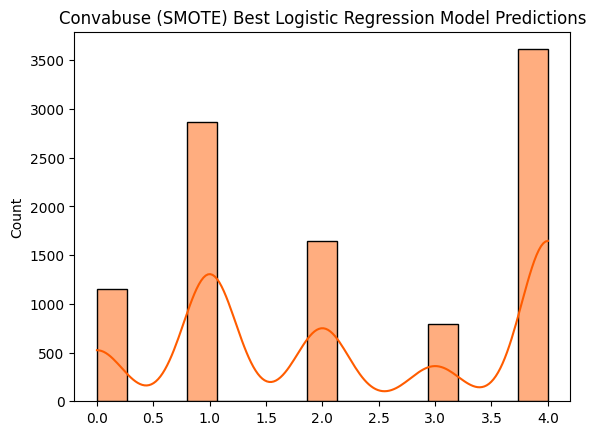

In [33]:
# Plot the predictions that were generated as a histogram using seaborn colored by correct vs incorrect predictions
sns.histplot(convabuse_y_pred, kde=True, color=middle_color)
plt.title(f"Convabuse ({balance}) Best Logistic Regression Model Predictions")
plt.show()

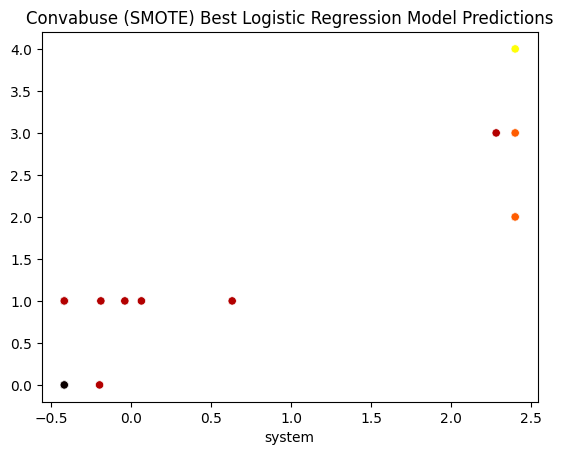

In [34]:
# Plot the predictions that were generated as a scatterplot plotted against the best correlated feature
sns.scatterplot(x=convabuse_X_test[convabuse_best_correlated_feature], y=convabuse_y_pred, c=convabuse_y_test, cmap='hot')
plt.title(f"Convabuse ({balance}) Best Logistic Regression Model Predictions")
plt.show()

In [35]:
# Classification report for the best model
print(classification_report(convabuse_y_test, convabuse_y_pred))

              precision    recall  f1-score   support

           0       0.69      0.39      0.50      2013
           1       0.57      0.82      0.67      2012
           2       0.63      0.51      0.57      2013
           3       0.40      0.16      0.22      2013
           4       0.47      0.84      0.60      2012

    accuracy                           0.54     10063
   macro avg       0.55      0.55      0.51     10063
weighted avg       0.55      0.54      0.51     10063



In [36]:
# Confusion matrix for the best model
convabuse_confusion_matrix = pd.crosstab(convabuse_y_test, convabuse_y_pred, rownames=["Actual"], colnames=["Predicted"])
convabuse_confusion_matrix

Predicted,0,1,2,3,4
Actual,,,,,
0,792,1221,0,0,0
1,358,1643,9,1,1
2,0,0,1036,312,665
3,0,0,450,315,1248
4,0,0,150,164,1698


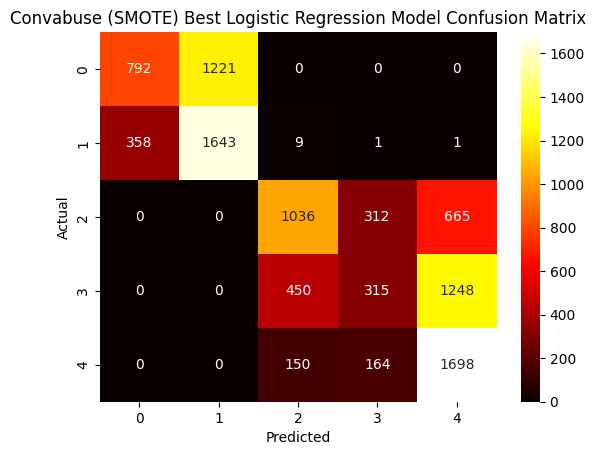

In [37]:
# Heatmap to visualize the confusion matrix
sns.heatmap(convabuse_confusion_matrix, annot=True, fmt="d", cmap="hot")
plt.title(f"Convabuse ({balance}) Best Logistic Regression Model Confusion Matrix")
plt.show()

In [38]:
# Calculate the feature importances
convabuse_feature_importances = pd.DataFrame({"Feature": convabuse_X_train.columns, "Importance": convabuse_best_model.coef_[0]})
convabuse_feature_importances = convabuse_feature_importances.sort_values(by="Importance", ascending=False)
convabuse_feature_importances

,Feature,Importance
1,bot,0.585923
2,generalised,0.000000
3,individual,0.000000
7,target_groups,-0.188494
0,annotator_id,-0.249857
6,implicit,-0.356458
5,explicit,-2.998925
4,system,-4.289003


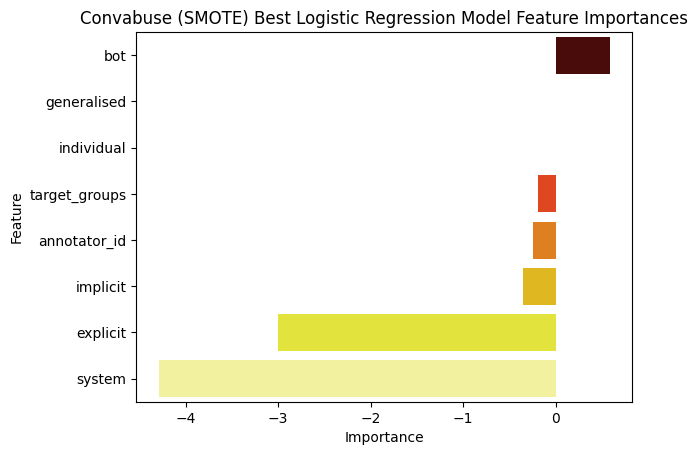

In [39]:
# Plot the feature importances
sns.barplot(x="Importance", y="Feature", data=convabuse_feature_importances, palette="hot")
plt.title(f"Convabuse ({balance}) Best Logistic Regression Model Feature Importances")
plt.show()

In [40]:
# Convert the feature importances to a dictionary
convabuse_feature_importances_dict = convabuse_feature_importances.set_index("Feature")["Importance"].to_dict()
logistic_regression_model_results.append(("Convabuse", convabuse_best_model_params["Regularizer"], convabuse_best_model_params["Solver"], convabuse_accuracy, convabuse_f1_score, 0.0, convabuse_feature_importances_dict))

## Dynamicaly Generated Hate Speech Logistic Regression

In [41]:
dghs_results_list = []

# Use logistic regression with L1, L2, and ElasticNet regularization with standardized features of the Dynamically Generated Hate Speech dataset
for regularizer in regularizers:
  for solver in solvers:
    if regularizer == "l1" and solver not in ["liblinear", "saga"]:
      continue
    dghs_logistic_regression = LogisticRegression(penalty=regularizer, solver=solver, random_state=42)
    dghs_logistic_regression.fit(dghs_X_train, dghs_y_train)
    # Predict the target variable for the test set
    dghs_y_pred = dghs_logistic_regression.predict(dghs_X_test)

    # Calculate the accuracy of the model
    dghs_accuracy = accuracy_score(dghs_y_test, dghs_y_pred)
    dghs_f1_score = f1_score(dghs_y_test, dghs_y_pred)
    dghs_results_list.append(("DGHS", regularizer, solver, dghs_accuracy, dghs_f1_score, 0))
    print(f"Regularizer: {regularizer}, Solver: {solver}, Accuracy: {dghs_accuracy}, F1-score: {dghs_f1_score}")

Regularizer: l1, Solver: liblinear, Accuracy: 0.8384160218479745, F1-score: 0.8072747014115093
Regularizer: l1, Solver: saga, Accuracy: 0.8384160218479745, F1-score: 0.8072747014115093
Regularizer: l2, Solver: lbfgs, Accuracy: 0.8384160218479745, F1-score: 0.8072747014115093
Regularizer: l2, Solver: liblinear, Accuracy: 0.8384160218479745, F1-score: 0.8072747014115093
Regularizer: l2, Solver: newton-cg, Accuracy: 0.8384160218479745, F1-score: 0.8072747014115093
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.8384160218479745, F1-score: 0.8072747014115093
Regularizer: l2, Solver: sag, Accuracy: 0.8384160218479745, F1-score: 0.8072747014115093
Regularizer: l2, Solver: saga, Accuracy: 0.8384160218479745, F1-score: 0.8072747014115093


In [42]:
for ratio in l1_ratio_list:
    dghs_logistic_regression = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=ratio, random_state=42)
    dghs_logistic_regression.fit(dghs_X_train, dghs_y_train)
    # Predict the target variable for the test set
    dghs_y_pred = dghs_logistic_regression.predict(dghs_X_test)

    # Calculate the accuracy of the model
    dghs_accuracy = accuracy_score(dghs_y_test, dghs_y_pred)
    dghs_f1_score = f1_score(dghs_y_test, dghs_y_pred)
    dghs_results_list.append(("DGHS", "elasticnet", "saga", dghs_accuracy, dghs_f1_score, ratio))
    print(f"Regularizer: elasticnet, l1_ratio: {ratio}, Accuracy: {dghs_accuracy}, F1-score: {dghs_f1_score}")

Regularizer: elasticnet, l1_ratio: 0.1, Accuracy: 0.8384160218479745, F1-score: 0.8072747014115093
Regularizer: elasticnet, l1_ratio: 0.2, Accuracy: 0.8384160218479745, F1-score: 0.8072747014115093
Regularizer: elasticnet, l1_ratio: 0.3, Accuracy: 0.8384160218479745, F1-score: 0.8072747014115093
Regularizer: elasticnet, l1_ratio: 0.4, Accuracy: 0.8384160218479745, F1-score: 0.8072747014115093
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.8384160218479745, F1-score: 0.8072747014115093
Regularizer: elasticnet, l1_ratio: 0.6, Accuracy: 0.8384160218479745, F1-score: 0.8072747014115093
Regularizer: elasticnet, l1_ratio: 0.7, Accuracy: 0.8384160218479745, F1-score: 0.8072747014115093
Regularizer: elasticnet, l1_ratio: 0.8, Accuracy: 0.8384160218479745, F1-score: 0.8072747014115093
Regularizer: elasticnet, l1_ratio: 0.9, Accuracy: 0.8384160218479745, F1-score: 0.8072747014115093
Regularizer: elasticnet, l1_ratio: 1.0, Accuracy: 0.8384160218479745, F1-score: 0.8072747014115093


In [43]:
# Convert the results list into a dataframe
dghs_results = pd.DataFrame(dghs_results_list, columns=["Dataset", "Regularizer", "Solver", "Accuracy", "F1-score", "Ratio"])
dghs_results

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,DGHS,l1,liblinear,0.838416,0.807275,0.0
1,DGHS,l1,saga,0.838416,0.807275,0.0
2,DGHS,l2,lbfgs,0.838416,0.807275,0.0
3,DGHS,l2,liblinear,0.838416,0.807275,0.0
4,DGHS,l2,newton-cg,0.838416,0.807275,0.0
5,DGHS,l2,newton-cholesky,0.838416,0.807275,0.0
6,DGHS,l2,sag,0.838416,0.807275,0.0
7,DGHS,l2,saga,0.838416,0.807275,0.0
8,DGHS,elasticnet,saga,0.838416,0.807275,0.1
9,DGHS,elasticnet,saga,0.838416,0.807275,0.2


In [44]:
dghs_best_model_params = dghs_results.loc[dghs_results["Accuracy"].idxmax()]
dghs_best_model_params

,0
Dataset,DGHS
Regularizer,l1
Solver,liblinear
Accuracy,0.838416
F1-score,0.807275
Ratio,0.0


In [45]:
# Use the best parameters to create a new best model
dghs_best_model = LogisticRegression(penalty=dghs_best_model_params["Regularizer"], solver=dghs_best_model_params["Solver"], random_state=42)
dghs_best_model.fit(dghs_X_train, dghs_y_train)

# Predict the target variable for the test set
dghs_y_pred = dghs_best_model.predict(dghs_X_test)

# Calculate the accuracy of the model
dghs_accuracy = accuracy_score(dghs_y_test, dghs_y_pred)
dghs_f1_score = f1_score(dghs_y_test, dghs_y_pred)

print(f"Regularizer: {dghs_best_model_params['Regularizer']}, Solver: {dghs_best_model_params['Solver']}, Accuracy: {dghs_accuracy}, F1-score: {dghs_f1_score}")

Regularizer: l1, Solver: liblinear, Accuracy: 0.8384160218479745, F1-score: 0.8072747014115093


In [46]:
# Get the best correlated feature with the target variable
dghs_best_correlated_feature = dghs_X_train.corrwith(dghs_y_train).abs().idxmax()
dghs_best_correlated_feature

'type'

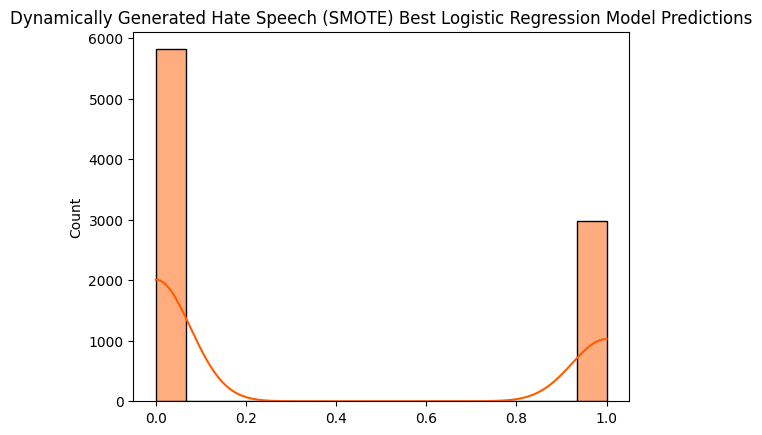

In [47]:
# Plot the predictions that were generated as a histogram using seaborn colored by correct vs incorrect predictions
sns.histplot(dghs_y_pred, kde=True, palette='hot', color=middle_color)
plt.title(f"Dynamically Generated Hate Speech ({balance}) Best Logistic Regression Model Predictions")
plt.show()

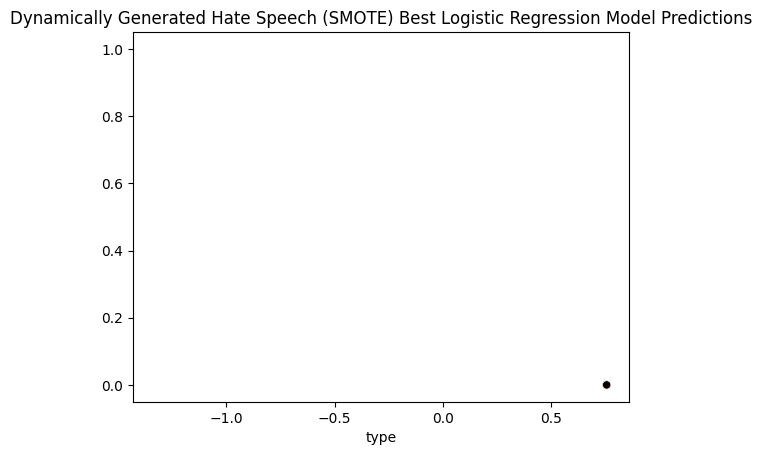

In [48]:
# Plot the predictions that were generated as a scatterplot plotted against the best correlated feature
sns.scatterplot(x=dghs_X_test[dghs_best_correlated_feature], y=dghs_y_pred, c=dghs_y_test, cmap='hot')
plt.title(f"Dynamically Generated Hate Speech ({balance}) Best Logistic Regression Model Predictions")
plt.show()

In [49]:
# Classification report for the best model
print(classification_report(dghs_y_test, dghs_y_pred))

              precision    recall  f1-score   support

         0.0       0.76      1.00      0.86      4394
         1.0       1.00      0.68      0.81      4394

    accuracy                           0.84      8788
   macro avg       0.88      0.84      0.83      8788
weighted avg       0.88      0.84      0.83      8788



In [50]:
# Confusion matrix for the best model
dghs_confusion_matrix = pd.crosstab(dghs_y_test, dghs_y_pred, rownames=["Actual"], colnames=["Predicted"])
dghs_confusion_matrix

Predicted,0.0,1.0
Actual,,
0.0,4394,0
1.0,1420,2974


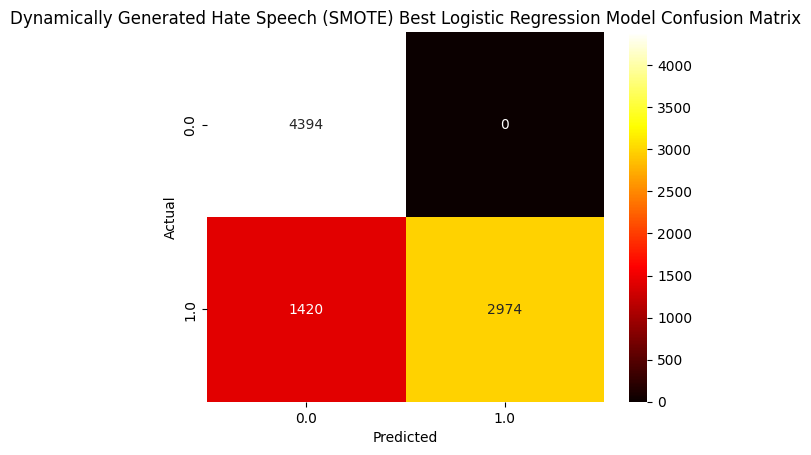

In [51]:
# Heatmap to visualize the confusion matrix
sns.heatmap(dghs_confusion_matrix, annot=True, fmt="d", cmap="hot")
plt.title(f"Dynamically Generated Hate Speech ({balance}) Best Logistic Regression Model Confusion Matrix")
plt.show()

In [52]:
# Calculate the feature importances
dghs_feature_importances = pd.DataFrame({"Feature": dghs_X_train.columns, "Importance": dghs_best_model.coef_[0]})
dghs_feature_importances = dghs_feature_importances.sort_values(by="Importance", ascending=False)
dghs_feature_importances

,Feature,Importance
3,original,3.871260
2,target_groups,0.170535
1,annotator,-0.221364
0,type,-8.193088


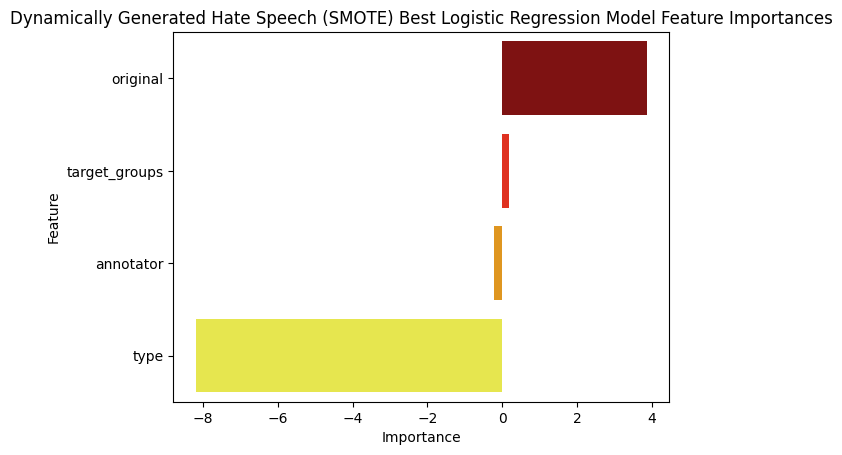

In [53]:
# Plot the feature importances
sns.barplot(x="Importance", y="Feature", data=dghs_feature_importances, palette="hot")
plt.title(f"Dynamically Generated Hate Speech ({balance}) Best Logistic Regression Model Feature Importances")
plt.show()

In [54]:
# Convert the feature importances to a dictionary
dghs_feature_importances_dict = dghs_feature_importances.set_index("Feature")["Importance"].to_dict()
logistic_regression_model_results.append(("DGHS", dghs_best_model_params["Regularizer"], dghs_best_model_params["Solver"], dghs_accuracy, dghs_f1_score, 0.0, dghs_feature_importances_dict))

## Online Abusive Attacks Logistic Regression

In [55]:
oaa_results_list = []

# Use logistic regression with L1, L2, and ElasticNet regularization with standardized features of the Dynamically Generated Hate Speech dataset
for regularizer in regularizers:
  for solver in solvers:
    if regularizer == "l1" and solver not in ["liblinear", "saga"]:
      continue
    oaa_logistic_regression = LogisticRegression(penalty=regularizer, solver=solver, random_state=42)
    oaa_logistic_regression.fit(oaa_X_train, oaa_y_train)
    # Predict the target variable for the test set
    oaa_y_pred = oaa_logistic_regression.predict(oaa_X_test)

    # Calculate the accuracy of the model
    oaa_accuracy = accuracy_score(oaa_y_test, oaa_y_pred)
    oaa_f1_score = f1_score(oaa_y_test, oaa_y_pred, average="weighted")
    oaa_results_list.append(("DGHS", regularizer, solver, oaa_accuracy, oaa_f1_score, 0))
    print(f"Regularizer: {regularizer}, Solver: {solver}, Accuracy: {oaa_accuracy}, F1-score: {oaa_f1_score}")

Regularizer: l1, Solver: liblinear, Accuracy: 0.8992805755395683, F1-score: 0.8966641712632039
Regularizer: l1, Solver: saga, Accuracy: 0.9037769784172662, F1-score: 0.8983977358185116
Regularizer: l2, Solver: lbfgs, Accuracy: 0.9028776978417267, F1-score: 0.8972059964644562
Regularizer: l2, Solver: liblinear, Accuracy: 0.8561151079136691, F1-score: 0.8486628663893974
Regularizer: l2, Solver: newton-cg, Accuracy: 0.9028776978417267, F1-score: 0.8972059964644562
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.9028776978417267, F1-score: 0.8972059964644562
Regularizer: l2, Solver: sag, Accuracy: 0.9028776978417267, F1-score: 0.8972059964644562
Regularizer: l2, Solver: saga, Accuracy: 0.8965827338129496, F1-score: 0.8900325894365535


In [56]:
for ratio in l1_ratio_list:
    oaa_logistic_regression = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=ratio, random_state=42)
    oaa_logistic_regression.fit(oaa_X_train, oaa_y_train)
    # Predict the target variable for the test set
    oaa_y_pred = oaa_logistic_regression.predict(oaa_X_test)

    # Calculate the accuracy of the model
    oaa_accuracy = accuracy_score(oaa_y_test, oaa_y_pred)
    oaa_f1_score = f1_score(oaa_y_test, oaa_y_pred, average="weighted")
    oaa_results_list.append(("DGHS", "elasticnet", "saga", oaa_accuracy, oaa_f1_score, ratio))
    print(f"Regularizer: elasticnet, l1_ratio: {ratio}, Accuracy: {oaa_accuracy}, F1-score: {oaa_f1_score}")

Regularizer: elasticnet, l1_ratio: 0.1, Accuracy: 0.8965827338129496, F1-score: 0.8900325894365535
Regularizer: elasticnet, l1_ratio: 0.2, Accuracy: 0.9010791366906474, F1-score: 0.8954311496077355
Regularizer: elasticnet, l1_ratio: 0.3, Accuracy: 0.9010791366906474, F1-score: 0.8954311496077355
Regularizer: elasticnet, l1_ratio: 0.4, Accuracy: 0.9010791366906474, F1-score: 0.8954311496077355
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.9010791366906474, F1-score: 0.8954311496077355
Regularizer: elasticnet, l1_ratio: 0.6, Accuracy: 0.9010791366906474, F1-score: 0.8954311496077355
Regularizer: elasticnet, l1_ratio: 0.7, Accuracy: 0.9010791366906474, F1-score: 0.8954311496077355
Regularizer: elasticnet, l1_ratio: 0.8, Accuracy: 0.9010791366906474, F1-score: 0.8954311496077355
Regularizer: elasticnet, l1_ratio: 0.9, Accuracy: 0.9028776978417267, F1-score: 0.8973530589610462
Regularizer: elasticnet, l1_ratio: 1.0, Accuracy: 0.9037769784172662, F1-score: 0.8983977358185116


In [57]:
# Convert the results list into a dataframe
oaa_results = pd.DataFrame(oaa_results_list, columns=["Dataset", "Regularizer", "Solver", "Accuracy", "F1-score", "Ratio"])
oaa_results

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,DGHS,l1,liblinear,0.899281,0.896664,0.0
1,DGHS,l1,saga,0.903777,0.898398,0.0
2,DGHS,l2,lbfgs,0.902878,0.897206,0.0
3,DGHS,l2,liblinear,0.856115,0.848663,0.0
4,DGHS,l2,newton-cg,0.902878,0.897206,0.0
5,DGHS,l2,newton-cholesky,0.902878,0.897206,0.0
6,DGHS,l2,sag,0.902878,0.897206,0.0
7,DGHS,l2,saga,0.896583,0.890033,0.0
8,DGHS,elasticnet,saga,0.896583,0.890033,0.1
9,DGHS,elasticnet,saga,0.901079,0.895431,0.2


In [58]:
oaa_best_model_params = oaa_results.loc[oaa_results["Accuracy"].idxmax()]
oaa_best_model_params

,1
Dataset,DGHS
Regularizer,l1
Solver,saga
Accuracy,0.903777
F1-score,0.898398
Ratio,0.0


In [59]:
# Use the best parameters to create a new best model
oaa_best_model = LogisticRegression(penalty=oaa_best_model_params["Regularizer"], solver=oaa_best_model_params["Solver"], random_state=42)
oaa_best_model.fit(oaa_X_train, oaa_y_train)

# Predict the target variable for the test set
oaa_y_pred = oaa_best_model.predict(oaa_X_test)

# Calculate the accuracy of the model
oaa_accuracy = accuracy_score(oaa_y_test, oaa_y_pred)
oaa_f1_score = f1_score(oaa_y_test, oaa_y_pred, average="weighted")

print(f"Regularizer: {oaa_best_model_params['Regularizer']}, Solver: {oaa_best_model_params['Solver']}, Accuracy: {oaa_accuracy}, F1-score: {oaa_f1_score}")

Regularizer: l1, Solver: saga, Accuracy: 0.9037769784172662, F1-score: 0.8983977358185116


In [60]:
# Get the best correlated feature with the target variable
oaa_best_correlated_feature = oaa_X_train.corrwith(oaa_y_train).abs().idxmax()
oaa_best_correlated_feature

'Toxic parent tweets'

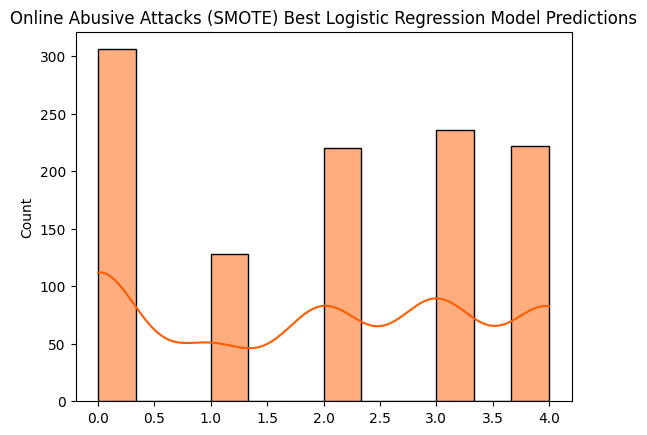

In [61]:
# Plot the predictions that were generated as a histogram using seaborn colored by correct vs incorrect predictions
sns.histplot(oaa_y_pred, kde=True, palette='hot', color=middle_color)
plt.title(f"Online Abusive Attacks ({balance}) Best Logistic Regression Model Predictions")
plt.show()

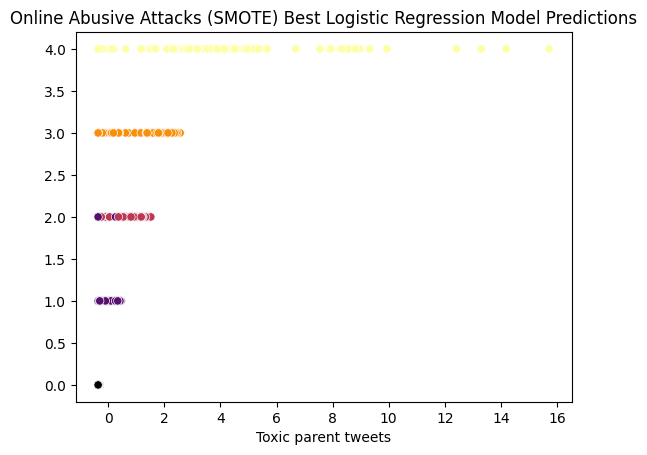

In [62]:
# Plot the predictions that were generated as a scatterplot plotted against the best correlated feature
sns.scatterplot(x=oaa_X_test[oaa_best_correlated_feature], y=oaa_y_pred, c=oaa_y_test, cmap='inferno')
plt.title(f"Online Abusive Attacks ({balance}) Best Logistic Regression Model Predictions")
plt.show()

In [63]:
# Classification report for the best model
print(classification_report(oaa_y_test, oaa_y_pred))

              precision    recall  f1-score   support

           0       0.73      1.00      0.84       223
           1       1.00      0.58      0.73       222
           2       0.95      0.94      0.95       222
           3       0.94      1.00      0.97       223
           4       1.00      1.00      1.00       222

    accuracy                           0.90      1112
   macro avg       0.92      0.90      0.90      1112
weighted avg       0.92      0.90      0.90      1112



In [64]:
# Confusion matrix for the best model
oaa_confusion_matrix = pd.crosstab(oaa_y_test, oaa_y_pred, rownames=["Actual"], colnames=["Predicted"])
oaa_confusion_matrix

Predicted,0,1,2,3,4
Actual,,,,,
0,223,0,0,0,0
1,83,128,11,0,0
2,0,0,209,13,0
3,0,0,0,223,0
4,0,0,0,0,222


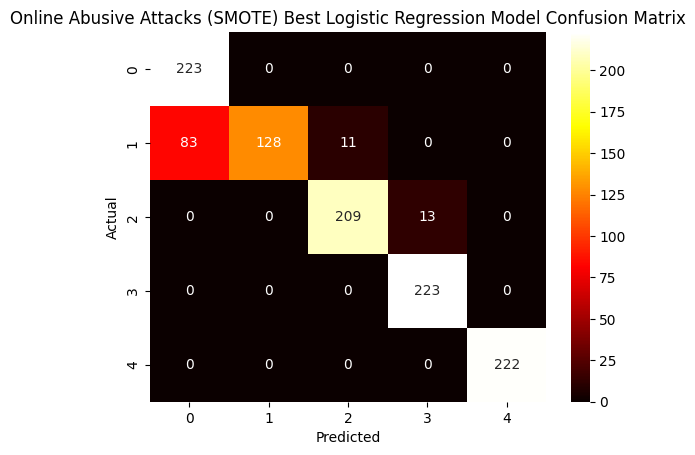

In [65]:
# Heatmap to visualize the confusion matrix
sns.heatmap(oaa_confusion_matrix, annot=True, fmt="d", cmap="hot")
plt.title(f"Online Abusive Attacks ({balance}) Best Logistic Regression Model Confusion Matrix")
plt.show()

In [66]:
# Calculate the feature importances
oaa_feature_importances = pd.DataFrame({"Feature": oaa_X_train.columns, "Importance": oaa_best_model.coef_[0]})
oaa_feature_importances = oaa_feature_importances.sort_values(by="Importance", ascending=False)
oaa_feature_importances

,Feature,Importance
1,Toxic replies,-7.789314
0,Toxic parent tweets,-17.035930


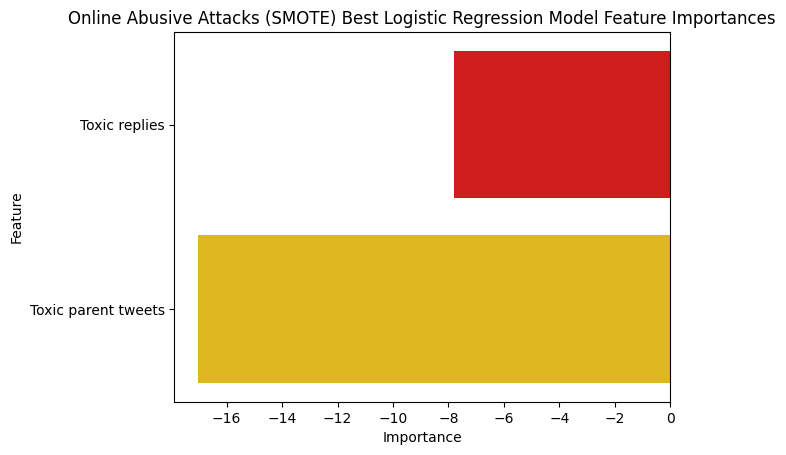

In [67]:
# Plot the feature importances
sns.barplot(x="Importance", y="Feature", data=oaa_feature_importances, palette="hot")
plt.title(f"Online Abusive Attacks ({balance}) Best Logistic Regression Model Feature Importances")
plt.show()

In [68]:
# Convert the feature importances to a dictionary
oaa_feature_importances_dict = oaa_feature_importances.set_index("Feature")["Importance"].to_dict()
logistic_regression_model_results.append(("Online Abusive Attacks", oaa_best_model_params["Regularizer"], oaa_best_model_params["Solver"], oaa_accuracy, oaa_f1_score, 0.0, oaa_feature_importances_dict))

In [69]:
oaa_feature_importances_dict

{'Toxic replies': -7.789314268739111,
 'Toxic parent tweets': -17.035930415870606}

## US Elections 2020 Hate Speech Logistic Regression

In [70]:
us2020hs_results_list = []

# Use logistic regression with L1, L2, and ElasticNet regularization with standardized features of the Dynamically Generated Hate Speech dataset
for regularizer in regularizers:
  for solver in solvers:
    if regularizer == "l1" and solver not in ["liblinear", "saga"]:
      continue
    us2020hs_logistic_regression = LogisticRegression(penalty=regularizer, solver=solver, random_state=42)
    us2020hs_logistic_regression.fit(us2020hs_X_train, us2020hs_y_train)
    # Predict the target variable for the test set
    us2020hs_y_pred = us2020hs_logistic_regression.predict(us2020hs_X_test)

    # Calculate the accuracy of the model
    us2020hs_accuracy = accuracy_score(us2020hs_y_test, us2020hs_y_pred)
    us2020hs_f1_score = f1_score(us2020hs_y_test, us2020hs_y_pred)
    us2020hs_results_list.append(("US2020HS", regularizer, solver, us2020hs_accuracy, us2020hs_f1_score, 0))
    print(f"Regularizer: {regularizer}, Solver: {solver}, Accuracy: {us2020hs_accuracy}, F1-score: {us2020hs_f1_score}")

Regularizer: l1, Solver: liblinear, Accuracy: 0.6486742424242424, F1-score: 0.6503298774740811
Regularizer: l1, Solver: saga, Accuracy: 0.6486742424242424, F1-score: 0.6503298774740811
Regularizer: l2, Solver: lbfgs, Accuracy: 0.6486742424242424, F1-score: 0.6503298774740811
Regularizer: l2, Solver: liblinear, Accuracy: 0.6486742424242424, F1-score: 0.6503298774740811
Regularizer: l2, Solver: newton-cg, Accuracy: 0.6486742424242424, F1-score: 0.6503298774740811
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.6486742424242424, F1-score: 0.6503298774740811
Regularizer: l2, Solver: sag, Accuracy: 0.6486742424242424, F1-score: 0.6503298774740811
Regularizer: l2, Solver: saga, Accuracy: 0.6486742424242424, F1-score: 0.6503298774740811


In [71]:
for ratio in l1_ratio_list:
    us2020hs_logistic_regression = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=ratio, random_state=42)
    us2020hs_logistic_regression.fit(us2020hs_X_train, us2020hs_y_train)
    # Predict the target variable for the test set
    us2020hs_y_pred = us2020hs_logistic_regression.predict(us2020hs_X_test)

    # Calculate the accuracy of the model
    us2020hs_accuracy = accuracy_score(us2020hs_y_test, us2020hs_y_pred)
    us2020hs_f1_score = f1_score(us2020hs_y_test, us2020hs_y_pred)
    us2020hs_results_list.append(("US2020HS", "elasticnet", "saga", us2020hs_accuracy, us2020hs_f1_score, ratio))
    print(f"Regularizer: elasticnet, l1_ratio: {ratio}, Accuracy: {us2020hs_accuracy}, F1-score: {us2020hs_f1_score}")

Regularizer: elasticnet, l1_ratio: 0.1, Accuracy: 0.6486742424242424, F1-score: 0.6503298774740811
Regularizer: elasticnet, l1_ratio: 0.2, Accuracy: 0.6486742424242424, F1-score: 0.6503298774740811
Regularizer: elasticnet, l1_ratio: 0.3, Accuracy: 0.6486742424242424, F1-score: 0.6503298774740811
Regularizer: elasticnet, l1_ratio: 0.4, Accuracy: 0.6486742424242424, F1-score: 0.6503298774740811
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.6486742424242424, F1-score: 0.6503298774740811
Regularizer: elasticnet, l1_ratio: 0.6, Accuracy: 0.6486742424242424, F1-score: 0.6503298774740811
Regularizer: elasticnet, l1_ratio: 0.7, Accuracy: 0.6486742424242424, F1-score: 0.6503298774740811
Regularizer: elasticnet, l1_ratio: 0.8, Accuracy: 0.6486742424242424, F1-score: 0.6503298774740811
Regularizer: elasticnet, l1_ratio: 0.9, Accuracy: 0.6486742424242424, F1-score: 0.6503298774740811
Regularizer: elasticnet, l1_ratio: 1.0, Accuracy: 0.6486742424242424, F1-score: 0.6503298774740811


In [72]:
# Convert the results list into a dataframe
us2020hs_results = pd.DataFrame(us2020hs_results_list, columns=["Dataset", "Regularizer", "Solver", "Accuracy", "F1-score", "Ratio"])
us2020hs_results

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,US2020HS,l1,liblinear,0.648674,0.65033,0.0
1,US2020HS,l1,saga,0.648674,0.65033,0.0
2,US2020HS,l2,lbfgs,0.648674,0.65033,0.0
3,US2020HS,l2,liblinear,0.648674,0.65033,0.0
4,US2020HS,l2,newton-cg,0.648674,0.65033,0.0
5,US2020HS,l2,newton-cholesky,0.648674,0.65033,0.0
6,US2020HS,l2,sag,0.648674,0.65033,0.0
7,US2020HS,l2,saga,0.648674,0.65033,0.0
8,US2020HS,elasticnet,saga,0.648674,0.65033,0.1
9,US2020HS,elasticnet,saga,0.648674,0.65033,0.2


In [73]:
us2020hs_best_model_params = us2020hs_results.loc[us2020hs_results["Accuracy"].idxmax()]
us2020hs_best_model_params

,0
Dataset,US2020HS
Regularizer,l1
Solver,liblinear
Accuracy,0.648674
F1-score,0.65033
Ratio,0.0


In [74]:
# Use the best parameters to create a new best model
us2020hs_best_model = LogisticRegression(penalty=us2020hs_best_model_params["Regularizer"], solver=us2020hs_best_model_params["Solver"], random_state=42)
us2020hs_best_model.fit(us2020hs_X_train, us2020hs_y_train)

# Predict the target variable for the test set
us2020hs_y_pred = us2020hs_best_model.predict(us2020hs_X_test)

# Calculate the accuracy of the best model
us2020hs_accuracy = accuracy_score(us2020hs_y_test, us2020hs_y_pred)
us2020hs_f1_score = f1_score(us2020hs_y_test, us2020hs_y_pred)

print(f"Regularizer: {us2020hs_best_model_params['Regularizer']}, Solver: {us2020hs_best_model_params['Solver']}, Accuracy: {us2020hs_accuracy}, F1-score: {us2020hs_f1_score}")

Regularizer: l1, Solver: liblinear, Accuracy: 0.6486742424242424, F1-score: 0.6503298774740811


In [75]:
# Get the best correlated feature with the target variable
us2020hs_best_correlated_feature = us2020hs_X_train.corrwith(us2020hs_y_train).abs().idxmax()
us2020hs_best_correlated_feature

'Trump'

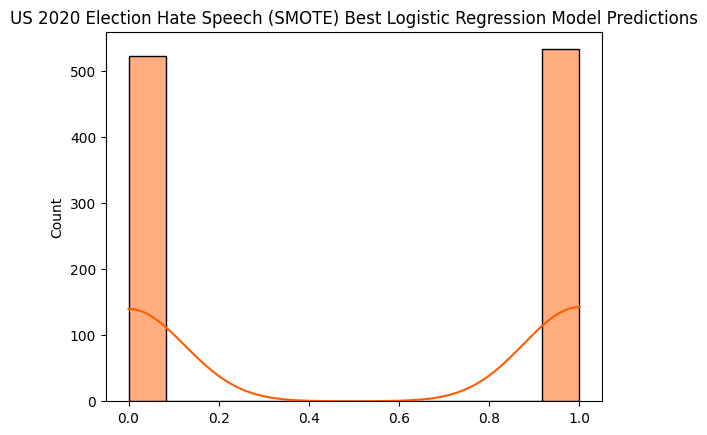

In [76]:
# Plot the predictions that were generated as a histogram using seaborn colored by correct vs incorrect predictions
sns.histplot(us2020hs_y_pred, kde=True, color=middle_color)
plt.title(f"US 2020 Election Hate Speech ({balance}) Best Logistic Regression Model Predictions")
plt.show()

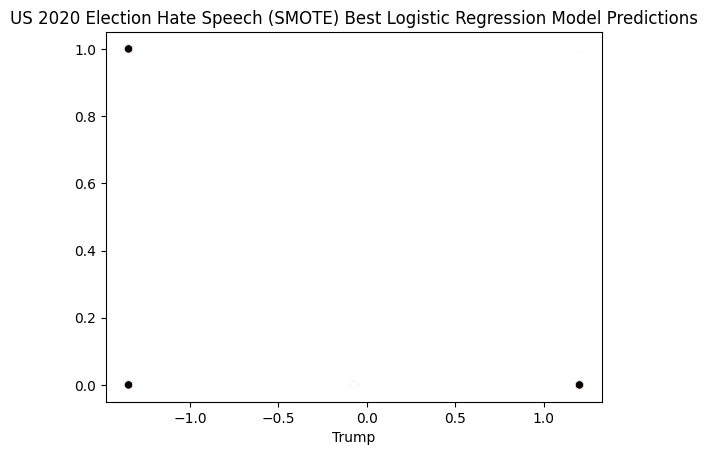

In [77]:
# Plot the predictions that were generated as a scatterplot plotted against the best correlated feature
sns.scatterplot(x=us2020hs_X_test[us2020hs_best_correlated_feature], y=us2020hs_y_pred, c=us2020hs_y_test, cmap='hot')
plt.title(f"US 2020 Election Hate Speech ({balance}) Best Logistic Regression Model Predictions")
plt.show()

In [78]:
# Classification report for the best model
print(classification_report(us2020hs_y_test, us2020hs_y_pred))

              precision    recall  f1-score   support

           0       0.65      0.64      0.65       528
           1       0.65      0.65      0.65       528

    accuracy                           0.65      1056
   macro avg       0.65      0.65      0.65      1056
weighted avg       0.65      0.65      0.65      1056



In [79]:
# Confusion matrix for the best model
us2020hs_confusion_matrix = pd.crosstab(us2020hs_y_test, us2020hs_y_pred, rownames=["Actual"], colnames=["Predicted"])
us2020hs_confusion_matrix

Predicted,0,1
Actual,,
0,340,188
1,183,345


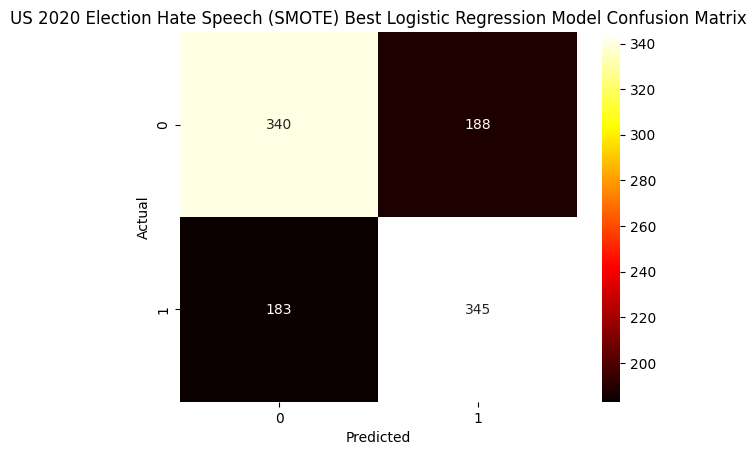

In [80]:
# Heatmap to visualize the confusion matrix
sns.heatmap(us2020hs_confusion_matrix, annot=True, fmt="d", cmap="hot")
plt.title(f"US 2020 Election Hate Speech ({balance}) Best Logistic Regression Model Confusion Matrix")
plt.show()

In [81]:
# Calculate the feature importances
us2020hs_feature_importances = pd.DataFrame({"Feature": us2020hs_X_train.columns, "Importance": us2020hs_best_model.coef_[0]})
us2020hs_feature_importances = us2020hs_feature_importances.sort_values(by="Importance", ascending=False)
us2020hs_feature_importances

,Feature,Importance
2,West,0.000000
1,Biden,-0.515770
0,Trump,-0.569883


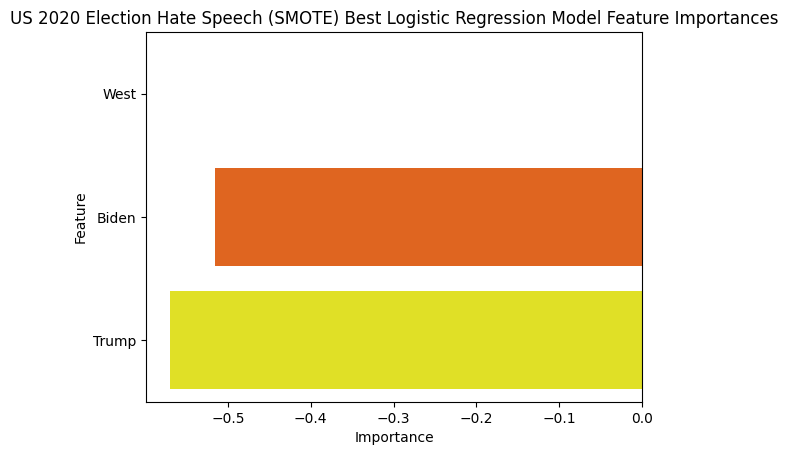

In [82]:
# Plot the feature importances
sns.barplot(x="Importance", y="Feature", data=us2020hs_feature_importances, palette="hot")
plt.title(f"US 2020 Election Hate Speech ({balance}) Best Logistic Regression Model Feature Importances")
plt.show()

In [83]:
# Convert the feature importances to a dictionary
us2020hs_feature_importances_dict = us2020hs_feature_importances.set_index("Feature")["Importance"].to_dict()
logistic_regression_model_results.append(("US2020HS", us2020hs_best_model_params["Regularizer"], us2020hs_best_model_params["Solver"], us2020hs_accuracy, us2020hs_f1_score, 0.0, us2020hs_feature_importances_dict))

## MLMA Hate Speech Logistic Regression

In [84]:
# Get a 10% sample of mlma_hate_speech_X_train
mlma_hate_speech_sample = mlma_hate_speech.sample(frac=0.3, random_state=42)

# Split into X and y
mlma_hate_speech_X_train_sample = mlma_hate_speech_sample.drop("target_groups", axis=1)
mlma_hate_speech_y_train_sample = mlma_hate_speech_sample["target_groups"]

# StandardScaler
mlma_hate_speech_X_train_scaled_sample = mlma_hate_speech_scaler.fit_transform(mlma_hate_speech_X_train_sample)
mlma_hate_speech_X_train_scaled_sample = pd.DataFrame(mlma_hate_speech_X_train_sample, columns=mlma_hate_speech_X_train.columns)

# Train-test-split
mlma_hate_speech_X_train_sample, mlma_hate_speech_X_test_sample, mlma_hate_speech_y_train_sample, mlma_hate_speech_y_test_sample = train_test_split(mlma_hate_speech_X_train_scaled_sample, mlma_hate_speech_y_train_sample, test_size=0.2, random_state=42)

In [85]:
mlma_hate_speech_results_list = []

# Use logistic regression with L1, L2, and ElasticNet regularization with standardized features of the Dynamically Generated Hate Speech dataset
for solver in ["liblinear", "saga"]:
  mlma_hate_speech_logistic_regression = LogisticRegression(penalty="l1", solver=solver, random_state=42)
  mlma_hate_speech_logistic_regression.fit(mlma_hate_speech_X_train_sample, mlma_hate_speech_y_train_sample)
  # Predict the target variable for the test set
  mlma_hate_speech_y_pred = mlma_hate_speech_logistic_regression.predict(mlma_hate_speech_X_test_sample)

  # Calculate the accuracy of the model
  mlma_hate_speech_accuracy = accuracy_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred)
  mlma_hate_speech_f1_score = f1_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred, average='weighted')
  mlma_hate_speech_results_list.append(("MLMA Hate Speech", regularizer, solver, mlma_hate_speech_accuracy, mlma_hate_speech_f1_score, 0))
  print(f"Regularizer: {regularizer}, Solver: {solver}, Accuracy: {mlma_hate_speech_accuracy}, F1-score: {mlma_hate_speech_f1_score}")

Regularizer: l2, Solver: liblinear, Accuracy: 0.575, F1-score: 0.4198412698412698
Regularizer: l2, Solver: saga, Accuracy: 0.575, F1-score: 0.4198412698412698


In [86]:
# Use logistic regression with L1, L2, and ElasticNet regularization with standardized features of the Dynamically Generated Hate Speech dataset
for solver in solvers:
  mlma_hate_speech_logistic_regression = LogisticRegression(penalty=regularizer, solver=solver, random_state=42)
  mlma_hate_speech_logistic_regression.fit(mlma_hate_speech_X_train_sample, mlma_hate_speech_y_train_sample)
  # Predict the target variable for the test set
  mlma_hate_speech_y_pred = mlma_hate_speech_logistic_regression.predict(mlma_hate_speech_X_test_sample)

  # Calculate the accuracy of the model
  mlma_hate_speech_accuracy = accuracy_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred)
  mlma_hate_speech_f1_score = f1_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred, average='weighted')
  mlma_hate_speech_results_list.append(("MLMA Hate Speech", regularizer, solver, mlma_hate_speech_accuracy, mlma_hate_speech_f1_score, 0))
  print(f"Regularizer: {regularizer}, Solver: {solver}, Accuracy: {mlma_hate_speech_accuracy}, F1-score: {mlma_hate_speech_f1_score}")

Regularizer: l2, Solver: lbfgs, Accuracy: 0.575, F1-score: 0.4198412698412698
Regularizer: l2, Solver: liblinear, Accuracy: 0.575, F1-score: 0.4198412698412698
Regularizer: l2, Solver: newton-cg, Accuracy: 0.575, F1-score: 0.4198412698412698
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.575, F1-score: 0.4198412698412698
Regularizer: l2, Solver: sag, Accuracy: 0.575, F1-score: 0.4198412698412698
Regularizer: l2, Solver: saga, Accuracy: 0.575, F1-score: 0.4198412698412698


In [87]:
for ratio in l1_ratio_list:
    mlma_hate_speech_logistic_regression = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=ratio, random_state=42)
    mlma_hate_speech_logistic_regression.fit(mlma_hate_speech_X_train_sample, mlma_hate_speech_y_train_sample)
    # Predict the target variable for the test set
    mlma_hate_speech_y_pred = mlma_hate_speech_logistic_regression.predict(mlma_hate_speech_X_test_sample)

    # Calculate the accuracy of the model
    mlma_hate_speech_accuracy = accuracy_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred)
    mlma_hate_speech_f1_score = f1_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred, average='weighted')
    mlma_hate_speech_results_list.append(("MLMA Hate Speech", "elasticnet", "saga", mlma_hate_speech_accuracy, mlma_hate_speech_f1_score, ratio))
    print(f"Regularizer: elasticnet, l1_ratio: {ratio}, Accuracy: {mlma_hate_speech_accuracy}, F1-score: {mlma_hate_speech_f1_score}")

Regularizer: elasticnet, l1_ratio: 0.1, Accuracy: 0.575, F1-score: 0.4198412698412698
Regularizer: elasticnet, l1_ratio: 0.2, Accuracy: 0.575, F1-score: 0.4198412698412698
Regularizer: elasticnet, l1_ratio: 0.3, Accuracy: 0.575, F1-score: 0.4198412698412698
Regularizer: elasticnet, l1_ratio: 0.4, Accuracy: 0.575, F1-score: 0.4198412698412698
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.575, F1-score: 0.4198412698412698
Regularizer: elasticnet, l1_ratio: 0.6, Accuracy: 0.575, F1-score: 0.4198412698412698
Regularizer: elasticnet, l1_ratio: 0.7, Accuracy: 0.575, F1-score: 0.4198412698412698
Regularizer: elasticnet, l1_ratio: 0.8, Accuracy: 0.575, F1-score: 0.4198412698412698
Regularizer: elasticnet, l1_ratio: 0.9, Accuracy: 0.575, F1-score: 0.4198412698412698
Regularizer: elasticnet, l1_ratio: 1.0, Accuracy: 0.575, F1-score: 0.4198412698412698


In [88]:
# Convert the results list into a dataframe
mlma_hate_speech_results = pd.DataFrame(mlma_hate_speech_results_list, columns=["Dataset", "Regularizer", "Solver", "Accuracy", "F1-score", "Ratio"])
mlma_hate_speech_results

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,MLMA Hate Speech,l2,liblinear,0.575,0.419841,0.0
1,MLMA Hate Speech,l2,saga,0.575,0.419841,0.0
2,MLMA Hate Speech,l2,lbfgs,0.575,0.419841,0.0
3,MLMA Hate Speech,l2,liblinear,0.575,0.419841,0.0
4,MLMA Hate Speech,l2,newton-cg,0.575,0.419841,0.0
5,MLMA Hate Speech,l2,newton-cholesky,0.575,0.419841,0.0
6,MLMA Hate Speech,l2,sag,0.575,0.419841,0.0
7,MLMA Hate Speech,l2,saga,0.575,0.419841,0.0
8,MLMA Hate Speech,elasticnet,saga,0.575,0.419841,0.1
9,MLMA Hate Speech,elasticnet,saga,0.575,0.419841,0.2


In [89]:
mlma_hate_speech_best_model_params = mlma_hate_speech_results.loc[mlma_hate_speech_results["Accuracy"].idxmax()]
mlma_hate_speech_best_model_params

,0
Dataset,MLMA Hate Speech
Regularizer,l2
Solver,liblinear
Accuracy,0.575
F1-score,0.419841
Ratio,0.0


In [90]:
# Use the best parameters to create a new best model
mlma_hate_speech_best_model = LogisticRegression(penalty="l2", solver="saga", random_state=42)
mlma_hate_speech_best_model.fit(mlma_hate_speech_X_train_sample, mlma_hate_speech_y_train_sample)

# Predict the target variable for the test set
mlma_hate_speech_y_pred = mlma_hate_speech_best_model.predict(mlma_hate_speech_X_test_sample)

# Calculate the accuracy of the best model
mlma_hate_speech_accuracy = accuracy_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred)
mlma_hate_speech_f1_score = f1_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred, average="weighted")

print(f"Regularizer: {mlma_hate_speech_best_model_params['Regularizer']}, Solver: {mlma_hate_speech_best_model_params['Solver']}, Accuracy: {mlma_hate_speech_accuracy}, F1-score: {mlma_hate_speech_f1_score}")

Regularizer: l2, Solver: liblinear, Accuracy: 0.575, F1-score: 0.4198412698412698


In [91]:
logistic_regression_model_results

[('Convabuse',
  'l1',
  'saga',
  0.5449667097287091,
  0.5138897217352629,
  0.0,
  {'bot': 0.5859231731296082,
   'generalised': 0.0,
   'individual': 0.0,
   'target_groups': -0.18849388453333835,
   'annotator_id': -0.24985701737357588,
   'implicit': -0.3564580846565524,
   'explicit': -2.998925457784901,
   'system': -4.289003417150241}),
 ('DGHS',
  'l1',
  'liblinear',
  0.8384160218479745,
  0.8072747014115093,
  0.0,
  {'original': 3.871260109046368,
   'target_groups': 0.17053479748690822,
   'annotator': -0.22136398557444983,
   'type': -8.193088223102611}),
 ('Online Abusive Attacks',
  'l1',
  'saga',
  0.9037769784172662,
  0.8983977358185116,
  0.0,
  {'Toxic replies': -7.789314268739111,
   'Toxic parent tweets': -17.035930415870606}),
 ('US2020HS',
  'l1',
  'liblinear',
  0.6486742424242424,
  0.6503298774740811,
  0.0,
  {'West': 0.0, 'Biden': -0.5157701187647922, 'Trump': -0.5698827738030929})]

In [92]:
# Get the best correlated feature with the target variable
mlma_hate_speech_best_correlated_feature = mlma_hate_speech_X_train.corrwith(mlma_hate_speech_y_train).abs().idxmax()
mlma_hate_speech_best_correlated_feature

'implicit'

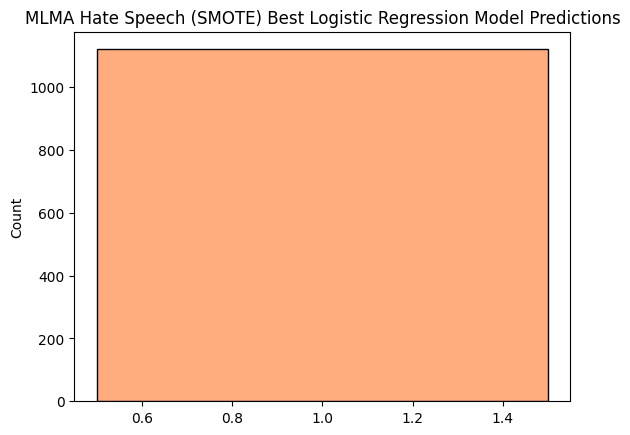

In [93]:
sns.histplot(mlma_hate_speech_y_pred, kde=True, color=middle_color)
plt.title(f"MLMA Hate Speech ({balance}) Best Logistic Regression Model Predictions")
plt.show()

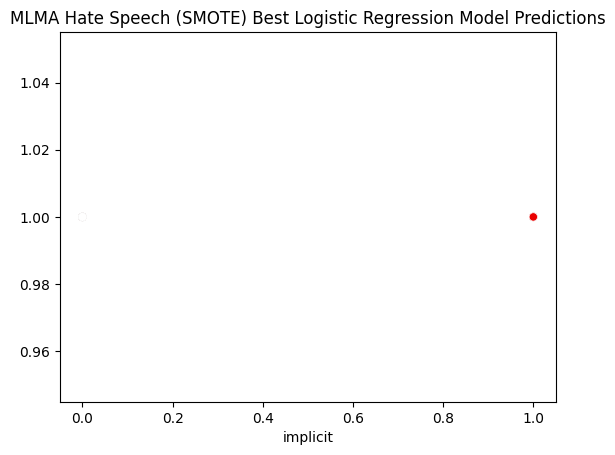

In [94]:
# Plot the predictions that were generated as a scatterplot plotted against the best correlated feature
sns.scatterplot(x=mlma_hate_speech_X_test_sample[mlma_hate_speech_best_correlated_feature], y=mlma_hate_speech_y_pred, c=mlma_hate_speech_y_test_sample, cmap='hot')
plt.title(f"MLMA Hate Speech ({balance}) Best Logistic Regression Model Predictions")
plt.show()

In [95]:
# Classification report for the best model
print(classification_report(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       277
           1       0.57      1.00      0.73       644
           2       0.00      0.00      0.00       177
           3       0.00      0.00      0.00        22

    accuracy                           0.57      1120
   macro avg       0.14      0.25      0.18      1120
weighted avg       0.33      0.57      0.42      1120



In [96]:
# Confusion matrix for the best model
mlma_hate_speech_confusion_matrix = pd.crosstab(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred, rownames=["Actual"], colnames=["Predicted"])
mlma_hate_speech_confusion_matrix

Predicted,1
Actual,
0,277
1,644
2,177
3,22


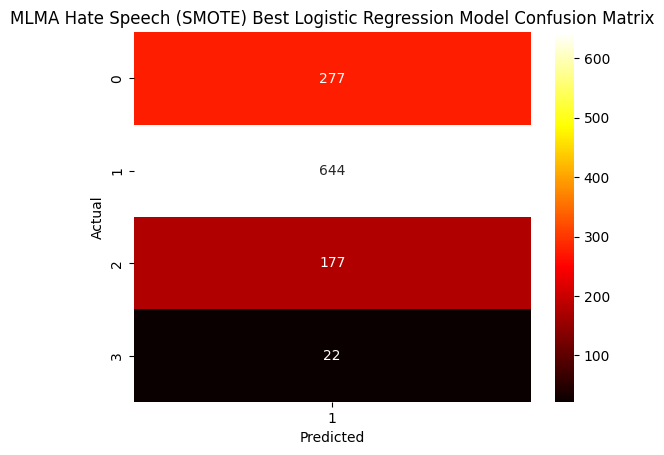

In [97]:
# Heatmap to visualize the confusion matrix
sns.heatmap(mlma_hate_speech_confusion_matrix, annot=True, fmt="d", cmap="hot")
plt.title(f"MLMA Hate Speech ({balance}) Best Logistic Regression Model Confusion Matrix")
plt.show()

In [98]:
# Calculate the feature importances
mlma_hate_speech_feature_importances = pd.DataFrame({"Feature": mlma_hate_speech_X_train_sample.columns, "Importance": mlma_hate_speech_best_model.coef_[0]})
mlma_hate_speech_feature_importances = mlma_hate_speech_feature_importances.sort_values(by="Importance", ascending=False)
mlma_hate_speech_feature_importances

,Feature,Importance
0,implicit,0.385936
3,abuse_level,0.027006
1,explicit,-0.217752
2,annotator_sentiment,-0.241416


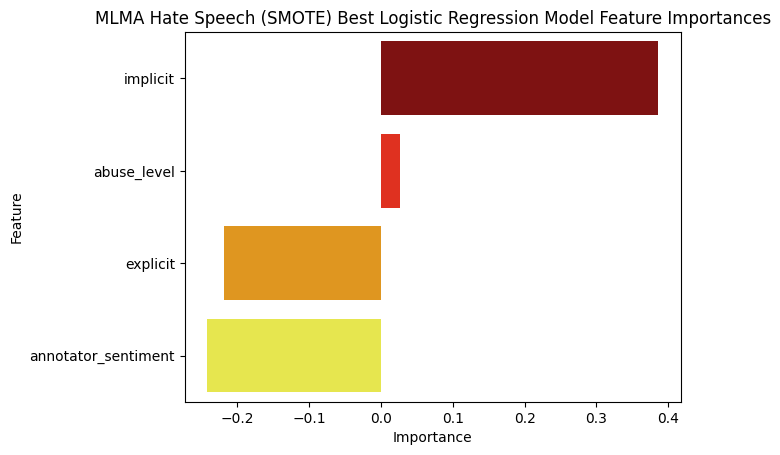

In [99]:
# Plot the feature importances
sns.barplot(x="Importance", y="Feature", data=mlma_hate_speech_feature_importances, palette="hot")
plt.title(f"MLMA Hate Speech ({balance}) Best Logistic Regression Model Feature Importances")
plt.show()

In [100]:
# Convert the feature importances to a dictionary
mlma_hate_speech_feature_importances_dict = mlma_hate_speech_feature_importances.set_index("Feature")["Importance"].to_dict()
logistic_regression_model_results.append(("MLMA Hate Speech", mlma_hate_speech_best_model_params["Regularizer"], mlma_hate_speech_best_model_params["Solver"], mlma_hate_speech_accuracy, mlma_hate_speech_f1_score, 0.0, mlma_hate_speech_feature_importances_dict))

## Logistic Regression Conclusions

In [101]:
logistic_regression_model_results

[('Convabuse',
  'l1',
  'saga',
  0.5449667097287091,
  0.5138897217352629,
  0.0,
  {'bot': 0.5859231731296082,
   'generalised': 0.0,
   'individual': 0.0,
   'target_groups': -0.18849388453333835,
   'annotator_id': -0.24985701737357588,
   'implicit': -0.3564580846565524,
   'explicit': -2.998925457784901,
   'system': -4.289003417150241}),
 ('DGHS',
  'l1',
  'liblinear',
  0.8384160218479745,
  0.8072747014115093,
  0.0,
  {'original': 3.871260109046368,
   'target_groups': 0.17053479748690822,
   'annotator': -0.22136398557444983,
   'type': -8.193088223102611}),
 ('Online Abusive Attacks',
  'l1',
  'saga',
  0.9037769784172662,
  0.8983977358185116,
  0.0,
  {'Toxic replies': -7.789314268739111,
   'Toxic parent tweets': -17.035930415870606}),
 ('US2020HS',
  'l1',
  'liblinear',
  0.6486742424242424,
  0.6503298774740811,
  0.0,
  {'West': 0.0, 'Biden': -0.5157701187647922, 'Trump': -0.5698827738030929}),
 ('MLMA Hate Speech',
  'l2',
  'liblinear',
  0.575,
  0.419841269841

In [102]:
# Combine the two results sets into a single logistic regression model summary
logistic_regression_model_summary = pd.concat([convabuse_results, dghs_results, oaa_results, us2020hs_results, mlma_hate_speech_results], ignore_index=True)
logistic_regression_model_summary

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,Convabuse,l1,liblinear,0.542482,0.504155,0.0
1,Convabuse,l1,saga,0.544967,0.513890,0.0
2,Convabuse,l2,lbfgs,0.544967,0.513895,0.0
3,Convabuse,l2,liblinear,0.542482,0.504155,0.0
4,Convabuse,l2,newton-cg,0.544867,0.513809,0.0
...,...,...,...,...,...,...
85,MLMA Hate Speech,elasticnet,saga,0.575000,0.419841,0.6
86,MLMA Hate Speech,elasticnet,saga,0.575000,0.419841,0.7
87,MLMA Hate Speech,elasticnet,saga,0.575000,0.419841,0.8
88,MLMA Hate Speech,elasticnet,saga,0.575000,0.419841,0.9


In [103]:
# Convert to a dataframe
logistic_regression_model_results = pd.DataFrame(logistic_regression_model_results, columns=["Dataset", "Regularizer", "Solver", "Accuracy", "F1-score", "Ratio", "Feature Importances"])
logistic_regression_model_results["Balance"] = "SMOTE"
logistic_regression_model_results["Model"] = "Logistic Regression"
logistic_regression_model_results

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio,Feature Importances,Balance,Model
0,Convabuse,l1,saga,0.544967,0.513890,0.0,"{'bot': 0.5859231731296082, 'generalised': 0.0...",SMOTE,Logistic Regression
1,DGHS,l1,liblinear,0.838416,0.807275,0.0,"{'original': 3.871260109046368, 'target_groups...",SMOTE,Logistic Regression
2,Online Abusive Attacks,l1,saga,0.903777,0.898398,0.0,"{'Toxic replies': -7.789314268739111, 'Toxic p...",SMOTE,Logistic Regression
3,US2020HS,l1,liblinear,0.648674,0.650330,0.0,"{'West': 0.0, 'Biden': -0.5157701187647922, 'T...",SMOTE,Logistic Regression
4,MLMA Hate Speech,l2,liblinear,0.575000,0.419841,0.0,"{'implicit': 0.3859362706501835, 'abuse_level'...",SMOTE,Logistic Regression


In [104]:
logistic_regression_model_results.to_csv("/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/results/model4_logistic-regression-summary_SMOTE.csv", index=False)